# Hands-on 1 — Molecular dynamics of a particle in a double well

We are going to write a **complete molecular-dynamics code** for the simplest possible system: **one particle moving in one dimension**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Part 1 — Deterministic dynamics

## 1. A simple harmonic potential

The simplest bound particle is one attached to a spring of stiffness $k$:

$$V(x) = \frac12 k x^2, \qquad F(x) = -\frac{\mathrm dV}{\mathrm dx} = -kx\,.$$

The motion is a pure oscillation of frequency $\omega = \sqrt{k/m}$: the exact solution of $m\ddot x = -V'(x)$ is

\begin{align*}
x(t) &= A \cos(\omega t + \Phi)\,, \\ v(t) &= -A \omega \sin(\omega t + \Phi)\,,
\end{align*}

where $A$ and $\Phi$ are fixed by the initial conditions $\big(x(0), v(0)\big)$.

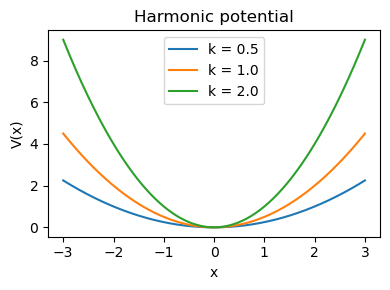

In [2]:
def V_harmonic(x, k=1.0):
    return 0.5 * k * x * x

x_grid = np.linspace(-3, 3, 200)
fig, ax = plt.subplots(figsize=(4, 3))
for k in [0.5, 1.0, 2.0]:
    ax.plot(x_grid, V_harmonic(x=x_grid, k=k), lw=1.5, label=f"k = {k}")
ax.set(xlabel="x", ylabel="V(x)", title="Harmonic potential")
ax.legend()
plt.tight_layout()

## 2. Velocity Verlet

We must solve $m\ddot x = F(x)$ numerically. We will use the **velocity Verlet**:

$$v(t+\tfrac{\Delta t}{2}) = v(t) + \frac{\Delta t}{2}\frac{F(t)}{m} \qquad\text{(half kick)}$$
$$x(t+\Delta t) = x(t) + \Delta t\, v(t+\tfrac{\Delta t}{2}) \qquad\text{(drift)}$$
$$v(t+\Delta t) = v(t+\tfrac{\Delta t}{2}) + \frac{\Delta t}{2}\frac{F(t+\Delta t)}{m}
   \qquad\text{(half kick)}$$

> **Question:** Without looking at the cell below, what is wrong in the equations above?

In [3]:
def f_harmonic(x, k=1.0):
    return -k * x

def velocity_verlet(x, v, force, dt, nsteps, m=1.0):
    """Integrate Newton's equations for 1D motion. 
    force is a function of x. Returns x(t), v(t)."""
    xs, vs = np.zeros(nsteps+1), np.zeros(nsteps+1)
    xs[0], vs[0] = x, v
    f = force(x)  # initial force
    for i in range(1,nsteps+1):
        v += 0.5 * dt * f / m       # half kick
        x += dt * v                 # drift
        f = force(x)                # new force
        v += 0.5 * dt * f / m       # half kick
        xs[i], vs[i] = x, v
    return xs, vs

Let's run a simulation from initial conditions $\big(x(0), v(0)\big) = (2, 0)$, using the $k=m=1$.
The exact solution is:

$$ x(t) = 2\cos t$$

The **global error** should be $O(\Delta t^2)$ (velocity Verlet is a **second-order** method).

dt = 0.01: 	 global_err / dt^2 = 0.813 	 dE / dt^2 = 0.500
dt = 0.02: 	 global_err / dt^2 = 0.813 	 dE / dt^2 = 0.500
dt = 0.05: 	 global_err / dt^2 = 0.812 	 dE / dt^2 = 0.500
dt = 0.10: 	 global_err / dt^2 = 0.811 	 dE / dt^2 = 0.500
dt = 0.20: 	 global_err / dt^2 = 0.804 	 dE / dt^2 = 0.500
dt = 0.50: 	 global_err / dt^2 = 0.755 	 dE / dt^2 = 0.500
dt = 1.00: 	 global_err / dt^2 = 0.481 	 dE / dt^2 = 0.375


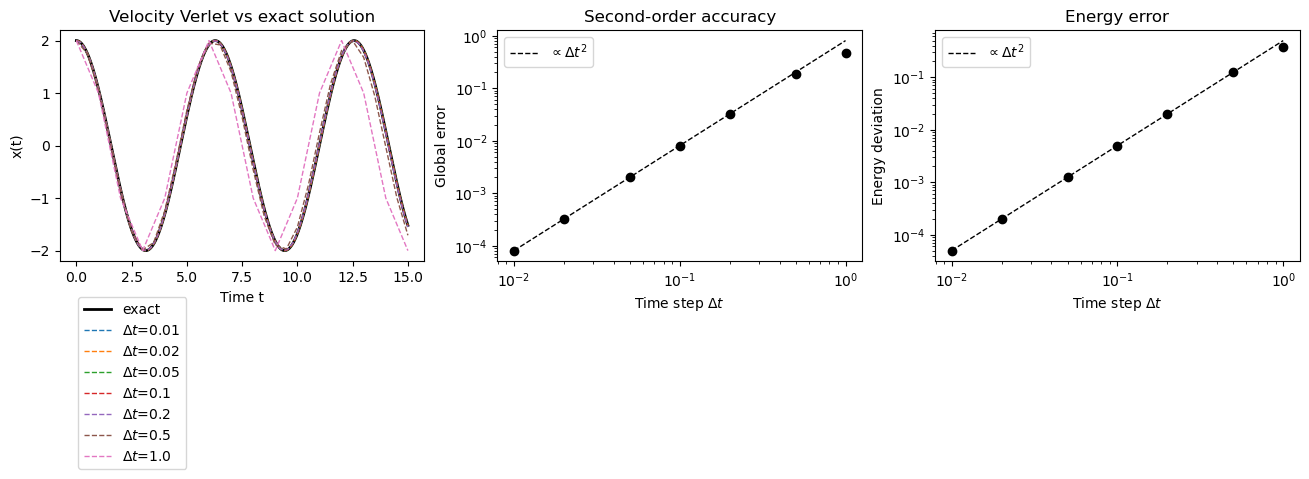

In [5]:
T = 15

# exact solution first
ts_fine = np.linspace(0, T, 2000)
xs_exact = 2 * np.cos(ts_fine)

fig, ax = plt.subplots(1, 3, figsize=(16, 3))
ax[0].plot(ts_fine, xs_exact, "k", lw=2, label="exact")

# velocity Verlet for different time steps
dts = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0])
errors, energy_errors = np.zeros(len(dts)), np.zeros(len(dts))

for i, dt in enumerate(dts):
    nsteps = int(T / dt)

    # integrate and plot
    xs, vs = velocity_verlet(x=2.0, v=0.0, force=f_harmonic, dt=dt, nsteps=nsteps)
    ts = np.arange(nsteps+1) * dt
    ax[0].plot(ts, xs, "--", lw=1, label=f"$\\Delta t$={dt}")

    # compute global error (deviation from exact solution at the final time)
    err = np.abs(xs - 2 * np.cos(ts))[-1]
    errors[i] = err
    ax[1].plot(dt, err, "ko", lw=1)

    # the energy is not conserved: measure the width of the band it explores
    E = 0.5 * vs**2 + 0.5 * xs**2
    dE = np.abs(E - E[0]).max()
    energy_errors[i] = dE
    ax[2].plot(dt, dE, "ko", lw=1)

    print(f"dt = {dt:.2f}: \t global_err / dt^2 = {err/dt**2:.3f} \t dE / dt^2 = {dE/dt**2:.3f}")

ax[1].plot(dts, 0.81 * dts**2, "k--", lw=1, label="$\\propto\\Delta t^2$")
ax[1].set(xscale="log", yscale="log")
ax[2].plot(dts, 0.50 * dts**2, "k--", lw=1, label="$\\propto\\Delta t^2$")
ax[2].set(xscale="log", yscale="log")

ax[0].set(xlabel="Time t", ylabel="x(t)", title="Velocity Verlet vs exact solution")
ax[0].legend(loc=(0.05, -0.9))
ax[1].set(xlabel="Time step $\\Delta t$", ylabel="Global error", title="Second-order accuracy")
ax[1].legend()
ax[2].set(xlabel="Time step $\\Delta t$", ylabel="Energy deviation", title="Energy error")
ax[2].legend()
plt.show()

> **Exercise**: try to increase the time step above. What happens to the quadratic behaviors? And why?

## 3. Time reversibility

Newton's equation $m\ddot x = F(x)$ is left unchanged by $t \to -t$: if $x(t)$ is a solution, so is $x(-t)$ (a movie of a trajectory played backwards is a legitimate trajectory as well).

Velocity Verlet inherits this property **exactly**. Writing one step as a map 
$(x_n, v_n) \mapsto (x_{n+1}, v_{n+1})$, one can check that

$$(x_{n+1},\, -v_{n+1}) \;\mapsto\; (x_n,\, -v_n)$$

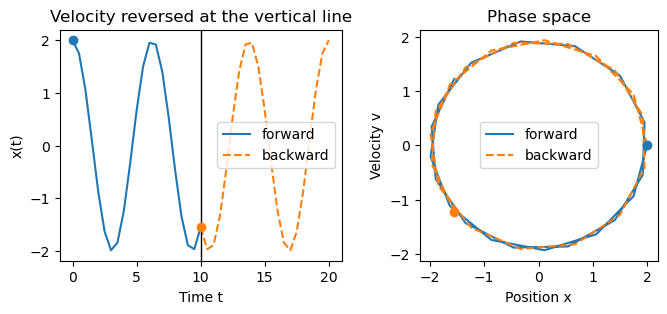

max |x mismatch| = 0.0e+00
max |v mismatch| = 0.0e+00


In [ ]:
dt, nsteps = 0.05, 90
x0, v0 = 2.0, 0.0

# forward, then backward from the last point with reversed velocity
xs_f, vs_f = velocity_verlet(x=x0, v=v0, force=f_harmonic, dt=dt, nsteps=nsteps)
xs_b, vs_b = velocity_verlet(x=xs_f[-1], v=-vs_f[-1], force=f_harmonic, dt=dt, nsteps=nsteps)

# plot x(t) and phase space trajectory
ts = np.arange(nsteps + 1) * dt
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(ts, xs_f, color="tab:blue", label="forward")
ax[0].plot(ts[-1] + ts, xs_b, color="tab:orange", ls="--", label="backward")
ax[0].axvline(ts[-1], color="k", lw=1, ls="-")
ax[0].plot(ts[0], x0, "o", color="tab:blue", ms=6)                        # start
ax[0].plot(ts[-1], xs_f[-1], "o", color="tab:orange", ms=6)          # reversal point

ax[1].plot(xs_f, vs_f, color="tab:blue", label="forward")
ax[1].plot(xs_b, vs_b, color="tab:orange", ls="--", label="backward")
ax[1].plot(x0, v0, "o", color="tab:blue", ms=6)                        # start
ax[1].plot(xs_f[-1], -vs_f[-1], "o", color="tab:orange", ms=6)          # reversal point

ax[0].set(xlabel="Time t", ylabel="x(t)", title="Velocity reversed at the vertical line")
ax[0].legend()
ax[1].set(xlabel="Position x", ylabel="Velocity v", title="Phase space", aspect="equal")
ax[1].legend()
plt.show()

# the backward trajectory, read in reverse order, is the forward one
print(f"max |x mismatch| = {np.abs(np.flip(xs_b) - xs_f).max():.1e}")
print(f"max |v mismatch| = {np.abs(np.flip(vs_b) + vs_f).max():.1e}")

> **Question:** Is this property satisfied in the limit of $\Delta t\rightarrow 0$, or for any $\Delta t$?

## 4. Why Verlet? Euler vs Verlet

The obvious way to integrate $\dot x = v$, $\dot v = F/m$ is the **explicit Euler** method:

$$x(t+\Delta t) = x(t) + \Delta t\,v(t), \qquad v(t+\Delta t) = v(t) + \Delta t\,\frac{F(t)}{m}$$

It is simpler than Verlet and, at first sight, just as reasonable. Let us compare what the two
do to the **total energy** $E = \tfrac12 mv^2 + V(x)$, which the exact dynamics conserves.

In [7]:
def euler(x, v, force, dt, nsteps, m=1.0):
    """Explicit Euler integrator."""
    xs, vs = np.zeros(nsteps+1), np.zeros(nsteps+1)
    xs[0], vs[0] = x, v
    for i in range(1, nsteps+1):
        x, v = x + dt * v, v + dt * force(x) / m
        xs[i], vs[i] = x, v
    return xs, vs

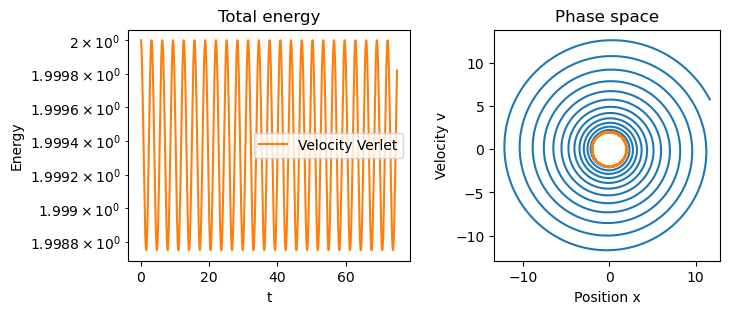

In [8]:
# simulation parameters
dt, nsteps = 0.05, 1500
x0, v0 = 2.0, 0.0

# integrate with both methods and compute energies
xv, vv = velocity_verlet(x=x0, v=v0, force=f_harmonic, dt=dt, nsteps=nsteps)
xe, ve = euler(x=x0, v=v0, force=f_harmonic, dt=dt, nsteps=nsteps)
E_verlet = 0.5 * vv**2 + 0.5 * xv**2 # kinetic + potential energy
E_euler = 0.5 * ve**2 + 0.5 * xe**2

# plot energy evolution (left) and phase space trajectory (right)
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
t = np.arange(nsteps + 1) * dt
#ax[0].plot(t, E_euler, '-', color="tab:blue", label="Euler")
ax[0].plot(t, E_verlet, '-', color="tab:orange", label="Velocity Verlet")
ax[1].plot(xe, ve, color="tab:blue")
ax[1].plot(xv, vv, color="tab:orange")

# plot details
ax[0].set(xlabel="t", ylabel="Energy", yscale="log", title="Total energy")
ax[0].legend()
ax[1].set(xlabel="Position x", ylabel="Velocity v", 
          title="Phase space", aspect="equal")
plt.show()

**Euler drifts:** its energy grows monotonically; in phase space the trajectory is not closed. It can be shown (try it!) that halving $\Delta t$ only slows the drift down, but never removes it.

**Verlet does not drift:** its energy oscillates within a narrow band and comes back; in phase space the orbit is closed.
Velocity Verlet is **symplectic**, i.e. it exactly preserves phase-space volume, and one can show it exactly conserves a "shadow" Hamiltonian
$\tilde H = H + \mathcal{O}(\Delta t^2)$ that stays close to the true $H$ forever. The energy
error therefore stays *bounded*.

This is why essentially every MD code — GROMACS, NAMD, LAMMPS — integrates with Verlet, and
why nobody uses Euler or Runge-Kutta for molecular dynamics, despite RK4 being "more accurate"
step for step.

## 5. Choosing the time step

The time step is the most important trade-off in MD. **Above a threshold, the integration becomes unstable.** For a harmonic oscillator of frequency $\omega$ one can show velocity Verlet is stable if and only if

$$\Delta t < \frac{2}{\omega}$$

With $k=m=1$ we have $\omega=1$, so the limit is $\Delta t = 2$.

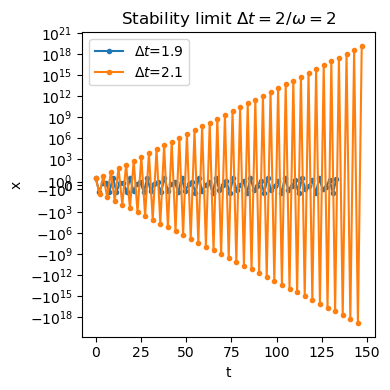

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))
nsteps = 70

for dt in [1.9, 2.1]:
    xs, vs = velocity_verlet(x=2.0, v=0.0, force=f_harmonic, dt=dt, nsteps=nsteps)
    ax.plot(np.arange(nsteps + 1) * dt, xs, "o-", ms=3, label=f"$\\Delta t$={dt}")
ax.set(xlabel="t", ylabel="x", yscale="symlog", title="Stability limit $\\Delta t = 2/\\omega = 2$")
ax.legend()
plt.tight_layout()

The practical rule: **$\Delta t$ must resolve the fastest oscillation in the system.** In a
real biomolecule (classical mechanics, no electron motion) the fastest motion is the stretching of bonds involving hydrogen
($\sim 10$ fs period), which is what limits classical MD to $\Delta t \approx 1$–$2$ fs.
Freezing those bonds with a constraint algorithm (LINCS, SHAKE) removes the fastest mode and allows larger time steps.

## 6. A more complicated potential

We switch now to a more complicated 2D potential energy: 

$$V(x,y) = h\left(x^2-1\right)^2 + \frac12\,k\,(y-x)^2, \qquad
  \mathbf F = \Big(-4hx\left(x^2-1\right) + k(y-x),\; -k(y-x)\Big)$$

Properties:

- two minima at $(\pm1,\pm1)$ with $V=0$, and 
- a saddle point at the origin of height $h$

With $h=k=1$ the Hessian at a minimum is $\left(\begin{smallmatrix} 8h+k & -k \\ -k & k\end{smallmatrix}\right)$, whose frequencies are $\omega = 0.94$ and $3.02$: the stability limit is $\Delta t < 2 / 3.02 \simeq 0.66$ and we keep $\Delta t = 0.01$.

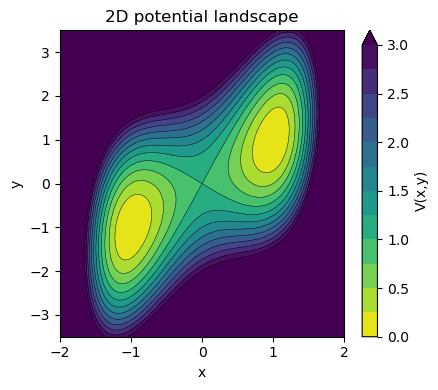

In [10]:
H, KS = 1.0, 1.0     # barrier height, spring constant

def V(r):
    x, y = r[0], r[1]
    return H * (x**2 - 1)**2 + 0.5 * KS * (y - x)**2

def force(r):
    x, y = r[0], r[1]
    return np.array([-4 * H * x * (x**2 - 1) + KS * (y - x), -KS * (y - x)])

# plot the landscape
x_grid = np.linspace(-2.0, 2.0, 400)
y_grid = np.linspace(-3.5, 3.5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
levels = np.linspace(0, 3.0, 13)

fig, ax = plt.subplots(figsize=(4.5, 4))
cf = ax.contourf(X, Y, V(r=(X, Y)), levels=levels, cmap="viridis_r", extend="max")
ax.contour(X, Y, V(r=(X, Y)), levels=levels, colors="k", linewidths=0.3)
ax.set(xlabel="x", ylabel="y", title="2D potential landscape")
fig.colorbar(cf, ax=ax, label="V(x,y)")
plt.tight_layout()

E = 2.0000 	 drift = 3.7e-04


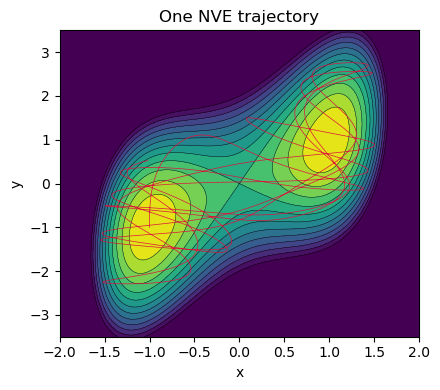

In [11]:
def velocity_verlet_2d(r, v, force, dt, nsteps, m=1.0):
    """The same integrator, for a particle moving in the plane."""
    rs, vs = np.zeros((nsteps+1, 2)), np.zeros((nsteps+1, 2))
    rs[0], vs[0] = r, v
    f = force(r)
    for i in range(1, nsteps+1):
        v = v + 0.5 * dt * f / m
        r = r + dt * v
        f = force(r)
        v = v + 0.5 * dt * f / m
        rs[i], vs[i] = r, v
    return rs, vs

dt, nsteps = 0.01, 4000
r0 = np.array([-1.0, -1.0])        # start at rest in the left well
v0 = np.array([0.0, 2.0])          # all the kinetic energy in the y mode

rs, vs = velocity_verlet_2d(r=r0, v=v0, force=force, dt=dt, nsteps=nsteps)
ts = np.arange(nsteps + 1) * dt
E = 0.5 * np.sum(vs**2, axis=1) + V(r=rs.T)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.contourf(X, Y, V(r=(X, Y)), levels=levels, cmap="viridis_r", extend="max")
ax.contour(X, Y, V(r=(X, Y)), levels=levels, colors="k", linewidths=0.3)
ax.plot(rs[:, 0], rs[:, 1], "crimson", lw=0.5)
ax.set(xlabel="x", ylabel="y", title="One NVE trajectory")#, aspect="equal")
plt.tight_layout()

print(f"E = {E[0]:.4f} \t drift = {np.abs(E - E[0]).max():.1e}")

# Part 2 — Temperature control

## 9. Theory review

So far the total energy was fixed: we sampled the **microcanonical (NVE)** ensemble. In experimental conditions, systems exchange energy with the surrounding environment, and what is fixed is the **temperature**. The right ensemble is the **canonical
(NVT)** one, in which a configuration appears with the Boltzmann probability

$$P(x,v)\;\propto\; e^{-\beta\left(\frac12 mv^2 + V(x)\right)},\qquad \beta = \frac{1}{k_BT}$$

Writing the corresponding NVT distribution as a function of the kinetic energy $K = \frac12 mv^2$ we get a **Gamma distribution**:

$$P(K)\;\propto\; K^{N_f / 2 -1} e^{-\beta K},\qquad N_f := \text{number of velocity components } (= 2 \text{ for us})$$

For $N_f = 2$ the exponent of $K$ vanishes and the Gamma law reduces to a plain
**exponential**, $P(K) \propto e^{-\beta K}$.

The mean value and variance of this distribution are:

$$\mathtt{E}[K]= \frac{N_f}{2}\,k_BT $$
$$ \text{Var}[K] = \mathtt{E}[K^2] - \mathtt{E}[K]^2 = \frac{N_f}{2}\,(k_BT)^2 $$


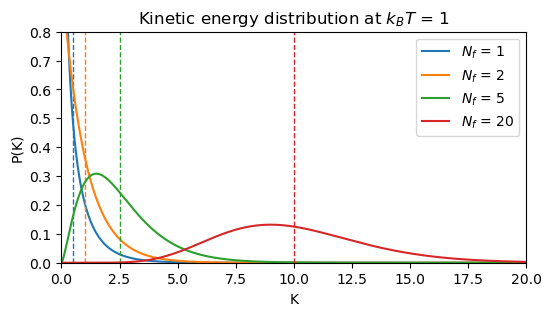

In [12]:
from math import gamma

def P_K(K, Nf, kT=1.0):
    """Gamma distribution of the kinetic energy."""
    a = 0.5 * Nf
    return K ** (a - 1) * np.exp(-K / kT) / (gamma(a) * kT ** a)

K = np.linspace(1e-3, 25, 800)

fig, ax = plt.subplots(1, figsize=(6, 3))
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
for i, Nf in enumerate([1, 2, 5, 20]):
    ax.plot(K, P_K(K=K, Nf=Nf), lw=1.5, label=f"$N_f$ = {Nf}", color=colors[i])

    mean = 0.5 * Nf                                 # <K> in units of k_B T
    ax.vlines(mean, 0, 0.8, color=colors[i], ls="--", lw=1)

ax.set(xlabel="K", ylabel="P(K)", xlim=(0, 20), ylim=(0, 0.8),
          title="Kinetic energy distribution at $k_BT$ = 1")
ax.legend()
plt.show()

## 10. The Berendsen thermostat

The natural way to control the temperature is to act on the kinetic energy directly. Berendsen
relaxes $K$ exponentially towards its canonical target $\bar K = \frac12 N_f k_BT_0$,

$$K' = c\,K + (1-c)\,\bar K, \qquad c = e^{-\Delta t/\tau}$$

To update the kinetic energy to the new value $K'$, all the velocities are rescaled by the same factor:

$$ v_i \;\mapsto\; \sqrt{K'/K}\;v_i \qquad \forall i $$

The parameter $\tau$ is a relaxation time, which sets how aggressively we correct. The algorithm is one thermostat call per MD step (compute $K$, update it, rescale the velocities).

The update is **deterministic** (no random numbers), and it is **global** — it touches every velocity at once, and only their common magnitude, never their direction.

In [13]:
def berendsen(v, T0, dt, tau, m=1.0):
    """Global and deterministic: relax K towards Kbar, then rescale the velocities."""
    Nf = np.size(v)
    K, Kbar = 0.5 * m * np.sum(v * v), 0.5 * Nf * T0
    c = np.exp(-dt / tau)
    Knew = c * K + (1.0 - c) * Kbar
    return np.sqrt(Knew / K) * v

def run_md(r, v, force, dt, nsteps, m=1.0, thermostat=None, T0=None, tau=None, stride=1):
    """Velocity Verlet in the plane, optionally followed by one thermostat step.
    The thermostat acts every `stride` steps (Andersen); every step for the others."""
    rs, vs = np.zeros((nsteps+1, 2)), np.zeros((nsteps+1, 2))
    rs[0], vs[0] = r, v
    f = force(r)
    for i in range(1, nsteps+1):
        v = v + 0.5 * dt * f / m
        r = r + dt * v
        f = force(r)
        v = v + 0.5 * dt * f / m

        if thermostat is not None and i % stride == 0:
            v = thermostat(v, T0, dt, tau, m)

        rs[i], vs[i] = r, v
    return rs, vs

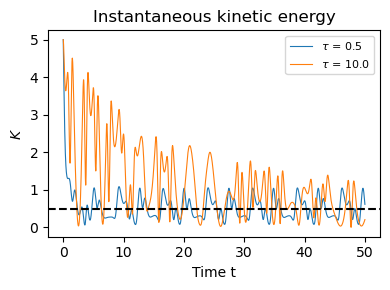

In [14]:
dt, nsteps = 0.01, 5000
ts = np.arange(nsteps + 1) * dt
T0, m = 0.5, 1.0
Kbar = 0.5 * 2 * T0        # target kinetic energy, N_f = 2
taus = [0.5, 10.0]         # tested relaxation times

fig, ax = plt.subplots(figsize=(4, 3))
for tau in taus:
    r0 = np.array([-1.0, -1.0])
    v0 = np.array([3.0, 1.0])          # start well out of equilibrium
    rs, vs = run_md(r=r0, v=v0, force=force, dt=dt, nsteps=nsteps,
                    thermostat=berendsen, T0=T0, tau=tau)
    K = 0.5 * m * np.sum(vs**2, axis=1)
    ax.plot(ts, K, lw=0.8, label=f"$\\tau$ = {tau}")

ax.axhline(Kbar, color="k", ls="--")
ax.set(xlabel="Time t", ylabel="$K$", title="Instantaneous kinetic energy")
ax.legend(fontsize=8)
plt.tight_layout()

The thermostat does what it promises: it makes the instantaneous kinetic relax towards the expected value. Now let us ask whether the sampled distribution is right:

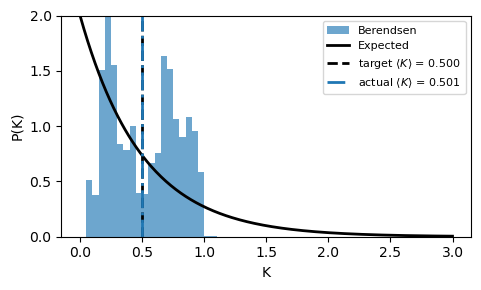

In [15]:
tau, nsteps = 1.0, 300000 # longer simulation
r0 = np.array([-1.0, -1.0])
v0 = np.array([3.0, 1.0]) 
rs, vs = run_md(r=r0, v=v0, force=force, dt=dt, nsteps=nsteps,
                thermostat=berendsen, T0=T0, tau=tau)
Ks = 0.5 * m * np.sum(vs**2, axis=1)

kgrid = np.linspace(1e-3, 3.0, 300)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(Ks, bins=60, range=(0, 3), color="tab:blue", density=True, alpha=0.65, label="Berendsen")
ax.plot(kgrid, P_K(K=kgrid, Nf=2, kT=T0), "k", lw=2, label="Expected")

ax.vlines(Kbar, 0, 2, color="k", ls="--", lw=2,
          label=f"target $\\langle K \\rangle$ = {Kbar:.3f}")
ax.vlines(Ks.mean(), 0, 2, color="tab:blue", ls="-.", lw=2,
          label=f"actual $\\langle K \\rangle$ = {Ks.mean():.3f}")
ax.set(xlabel="K", ylabel="P(K)", ylim=(0, 2))
ax.legend(fontsize=8)
plt.tight_layout()

>
> **Exercise:** How does the distribution change with $\\tau$$? Should does this say about this barostat?
>

## 11. The Andersen thermostat

The most direct way to impose a temperature: every $n_s$ steps (stride parameter), throw the velocities away and draw fresh ones from the exact Maxwell-Boltzmann distribution,

$$P(v_i) \;\propto\; e^{-\beta\,m v_i^2/2} \;\equiv\; \mathcal N\!\left(0,\, k_BT_0/m\right)
\qquad\Longrightarrow\qquad v_i \;\mapsto\; \sqrt{k_BT_0/m}\;\xi_i,\quad \xi_i\sim\mathcal N(0,1)$$

Between two resamplings the system runs pure Newtonian dynamics, so the algorithm alternates
stretches of NVE with sudden, total randomisations of the velocities. Since the new velocities come from precisely the right distribution, the sampling is correct **by construction**.

This thermostat is **stochastic** and **local**: each velocity component is drawn
on its own, so it has no difficulty sharing energy between the two modes.

In [16]:
def andersen(v, T0, dt, tau, m=1.0):
    """Local and stochastic: redraw every velocity from Maxwell-Boltzmann."""
    return np.sqrt(T0 / m) * rng.standard_normal(np.shape(v))

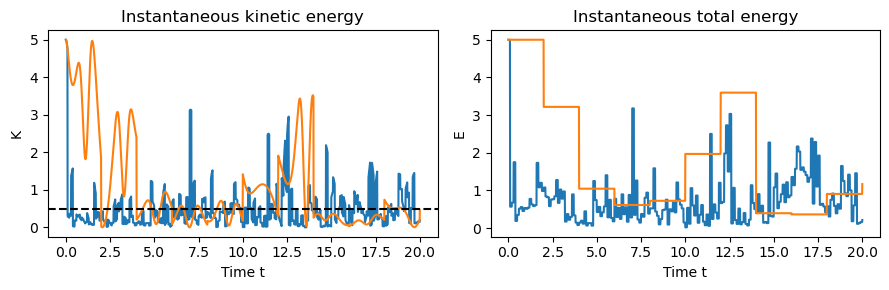

In [17]:
dt, nsteps = 0.01, 2000
ts = np.arange(nsteps + 1) * dt
r0 = np.array([-1.0, -1.0])
v0 = np.array([3.0, 1.0])
strides = [10, 200]  # tested stride values

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
for ns in strides:
    rs, vs = run_md(r=r0, v=v0, force=force, dt=dt, nsteps=nsteps,
                    thermostat=andersen, T0=T0, stride=ns)

    # plot kinetic energy and total energy evolutions
    K = 0.5 * m * np.sum(vs**2, axis=1)
    E_tot = K + V(r=rs.T)
    ax[0].plot(ts, K, label=f"$n_s$ = {ns}")
    ax[1].plot(ts, E_tot, label=f"$n_s$ = {ns}")


ax[0].axhline(Kbar, color="k", ls="--")
ax[0].set(xlabel="Time t", ylabel="K", title=f"Instantaneous kinetic energy")
ax[1].set(xlabel="Time t", ylabel="E", title=f"Instantaneous total energy")
plt.tight_layout()

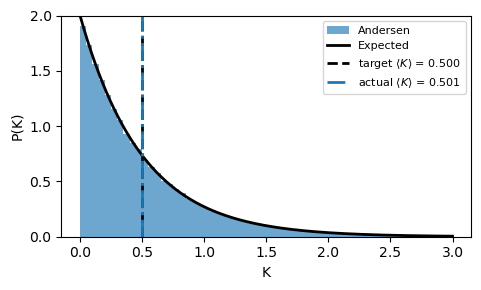

In [18]:
tau, nsteps = 1.0, 300000 # longer simulation
r0 = np.array([-1.0, -1.0])
v0 = np.array([3.0, 1.0]) 
rs, vs = run_md(r=r0, v=v0, force=force, dt=dt, nsteps=nsteps,
                thermostat=andersen, T0=T0, tau=tau)
Ks = 0.5 * m * np.sum(vs**2, axis=1)

kgrid = np.linspace(1e-3, 3.0, 300)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(Ks, bins=60, range=(0, 3), color="tab:blue", density=True, alpha=0.65, 
        label="Andersen")
ax.plot(kgrid, P_K(K=kgrid, Nf=2, kT=T0), "k", lw=2, label="Expected")

ax.vlines(Kbar, 0, 2, color="k", ls="--", lw=2,
          label=f"target $\\langle K \\rangle$ = {Kbar:.3f}")
ax.vlines(Ks.mean(), 0, 2, color="tab:blue", ls="-.", lw=2,
          label=f"actual $\\langle K \\rangle$ = {Ks.mean():.3f}")
ax.set(xlabel="K", ylabel="P(K)", ylim=(0, 2))
ax.legend(fontsize=8)
plt.tight_layout()

## 12. The Langevin thermostat

Berendsen rescales the velocities deterministically; Andersen throws them away and redraws them.
The **Langevin** thermostat sits exactly in between: at every step each velocity component is
partially forgotten and partially redrawn,

$$v_i \;\longmapsto\; c\,v_i + \sqrt{(1-c^2)\,\frac{k_BT_0}{m}}\;\xi_i, \qquad
  c = e^{-\Delta t/\tau}, \quad \xi_i \sim \mathcal N(0,1)$$

This is the exact solution, over one time step, of the Ornstein–Uhlenbeck equation

$$m\,\mathrm dv = -m\gamma\, v\,\mathrm dt + \sqrt{2m\gamma k_BT_0}\;\mathrm dW, \qquad \gamma = 1/\tau$$

i.e. of Newton's equation plus a **friction** $-m\gamma v$ and a **random force**. The two are not
independent: the amplitude of the noise is fixed by the friction and the temperature
(*fluctuation–dissipation theorem*), and it is precisely this relation that makes the stationary
distribution the Boltzmann one.

Three remarks:

* the thermostat is **local** (each component is treated on its own) and **stochastic**, like
  Andersen, but it is *gentle*: the velocity is only partially replaced;
* the two limits are the thermostats we already know: $\tau\to0$ gives $c\to0$, i.e. Andersen
  (redraw everything), and $\tau\to\infty$ gives $c\to1$, i.e. no thermostat at all (NVE);
* averaging the update above over the noise gives
  $\langle K'\rangle = c^2 K + (1-c^2)\bar K$, which is *exactly* the Berendsen rule of §10.
  **Berendsen is the noise-free average of Langevin** — and the noise is exactly what Berendsen is
  missing to sample the correct ensemble.

In [19]:
def langevin(v, T0, dt, tau, m=1.0):
    """Local and stochastic: partially forget the velocity, partially redraw it."""
    c = np.exp(-dt / tau)                      # friction, gamma = 1 / tau
    return c * v + np.sqrt((1 - c**2) * T0 / m) * rng.standard_normal(np.shape(v))

As for Berendsen, $\tau$ sets how fast the kinetic energy relaxes towards its target — but now it
fluctuates around it instead of collapsing onto it.

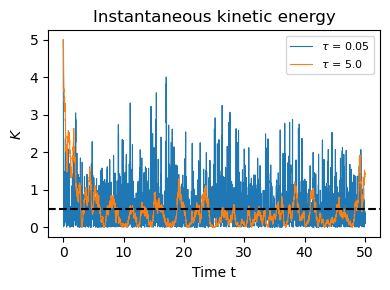

In [20]:
dt, nsteps = 0.01, 5000
ts = np.arange(nsteps + 1) * dt
taus = [0.05, 5.0]         # tested relaxation times

fig, ax = plt.subplots(figsize=(4, 3))
for tau in taus:
    r0 = np.array([-1.0, -1.0])
    v0 = np.array([3.0, 1.0])          # start well out of equilibrium
    rs, vs = run_md(r=r0, v=v0, force=force, dt=dt, nsteps=nsteps,
                    thermostat=langevin, T0=T0, tau=tau)
    K = 0.5 * m * np.sum(vs**2, axis=1)
    ax.plot(ts, K, lw=0.8, label=f"$\\tau$ = {tau}")

ax.axhline(Kbar, color="k", ls="--")
ax.set(xlabel="Time t", ylabel="$K$", title="Instantaneous kinetic energy")
ax.legend(fontsize=8)
plt.tight_layout()

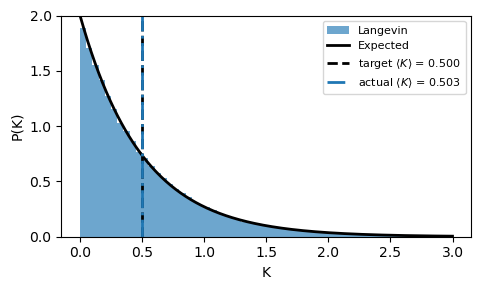

In [21]:
tau, nsteps = 1.0, 300000 # longer simulation
r0 = np.array([-1.0, -1.0])
v0 = np.array([3.0, 1.0])
rs, vs = run_md(r=r0, v=v0, force=force, dt=dt, nsteps=nsteps,
                thermostat=langevin, T0=T0, tau=tau)
Ks = 0.5 * m * np.sum(vs**2, axis=1)

kgrid = np.linspace(1e-3, 3.0, 300)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(Ks, bins=60, range=(0, 3), color="tab:blue", density=True, alpha=0.65,
        label="Langevin")
ax.plot(kgrid, P_K(K=kgrid, Nf=2, kT=T0), "k", lw=2, label="Expected")

ax.vlines(Kbar, 0, 2, color="k", ls="--", lw=2,
          label=f"target $\\langle K \\rangle$ = {Kbar:.3f}")
ax.vlines(Ks.mean(), 0, 2, color="tab:blue", ls="-.", lw=2,
          label=f"actual $\\langle K \\rangle$ = {Ks.mean():.3f}")
ax.set(xlabel="K", ylabel="P(K)", ylim=(0, 2))
ax.legend(fontsize=8)
plt.tight_layout()

Like Andersen, Langevin samples the canonical distribution correctly; unlike Andersen, it does not destroy the trajectory at every kick, so dynamical quantities keep some physical meaning (for $\tau$ large enough).